In [460]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [461]:
data = pd.read_csv("C:\\Users\\adity\\Desktop\\Python\\Project_Productivity\\garments_worker_productivity.csv")


In [462]:
data.head()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


# Smv
Represents 'Standard Minute Values' and it is defined as the time allocated for a task.

# Wip
Represents 'Work in progress'- includes the number of unfinished items for products.

In [463]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [464]:
data.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


In [465]:
data.department.unique()

array(['sweing', 'finishing ', 'finishing'], dtype=object)

# merging the department 'finishing' and 'finishing '

In [466]:
data['department'] = data['department'].str.strip()

# changing the incorrect spelling of sewing

In [467]:
#  replacement
data['department'] = data['department'].replace('sweing', 'sewing')

In [468]:
data.department.unique()

array(['sewing', 'finishing'], dtype=object)

# Check for missing values

In [469]:
data.isna().sum()

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64

In [470]:
dept = data.groupby(('department'))
dept.min()

,date,quarter,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
department,,,,,,,,,,,,,,
finishing,1/1/2015,Quarter1,Monday,1,0.35,2.90,NaN,0,0,0.0,0,0,2.0,0.235795
sewing,1/1/2015,Quarter1,Monday,1,0.07,10.05,7.0,0,0,0.0,0,0,26.0,0.233705


In [471]:
dept = data.groupby(('department'))
dept.max()

,date,quarter,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
department,,,,,,,,,,,,,,
finishing,3/9/2015,Quarter5,Wednesday,12,0.8,5.13,NaN,15000,3600,0.0,0,0,28.0,1.120437
sewing,3/9/2015,Quarter5,Wednesday,12,0.8,54.56,23122.0,25920,138,300.0,45,2,89.0,1.100484


In [472]:
idle_time = data.groupby(('idle_time'))
idle_time.max()

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_men,no_of_style_change,no_of_workers,actual_productivity
idle_time,,,,,,,,,,,,,,
0.0,3/9/2015,Quarter5,sewing,Wednesday,12,0.80,54.56,23122.0,25920,3600,0,2,89.0,1.120437
2.0,2/16/2015,Quarter3,sewing,Sunday,8,0.70,30.10,507.0,7080,40,10,2,59.0,0.700573
3.5,3/1/2015,Quarter4,sewing,Thursday,7,0.80,30.10,934.0,6960,63,20,1,59.5,0.799983
4.0,3/5/2015,Quarter1,sewing,Thursday,11,0.80,30.10,834.0,1200,50,40,0,59.0,0.682433
4.5,2/22/2015,Quarter4,sewing,Wednesday,8,0.80,30.10,962.0,5700,0,30,2,60.0,0.307501
5.0,2/19/2015,Quarter3,sewing,Tuesday,8,0.75,30.10,444.0,0,23,30,2,59.0,0.611141
6.5,3/3/2015,Quarter1,sewing,Tuesday,2,0.40,15.28,157.0,5400,0,30,1,45.0,0.302770
8.0,2/18/2015,Quarter3,sewing,Wednesday,10,0.70,19.68,1119.0,5640,0,35,1,49.0,0.303574
90.0,2/4/2015,Quarter1,sewing,Wednesday,5,0.65,30.10,326.0,5820,0,10,0,58.5,0.650835


# is idle time correlated with actual productivity ?


In [473]:
corr = data['idle_time'].corr(data['actual_productivity'])
print(corr)

-0.08085080966234484


since correlation coefficient comes out to be close to 0, therefore idle time is not correlated with actual productivity.

In [474]:
corr2 = data['over_time'].corr(data['actual_productivity'])
print(corr2)

-0.05420583714002144


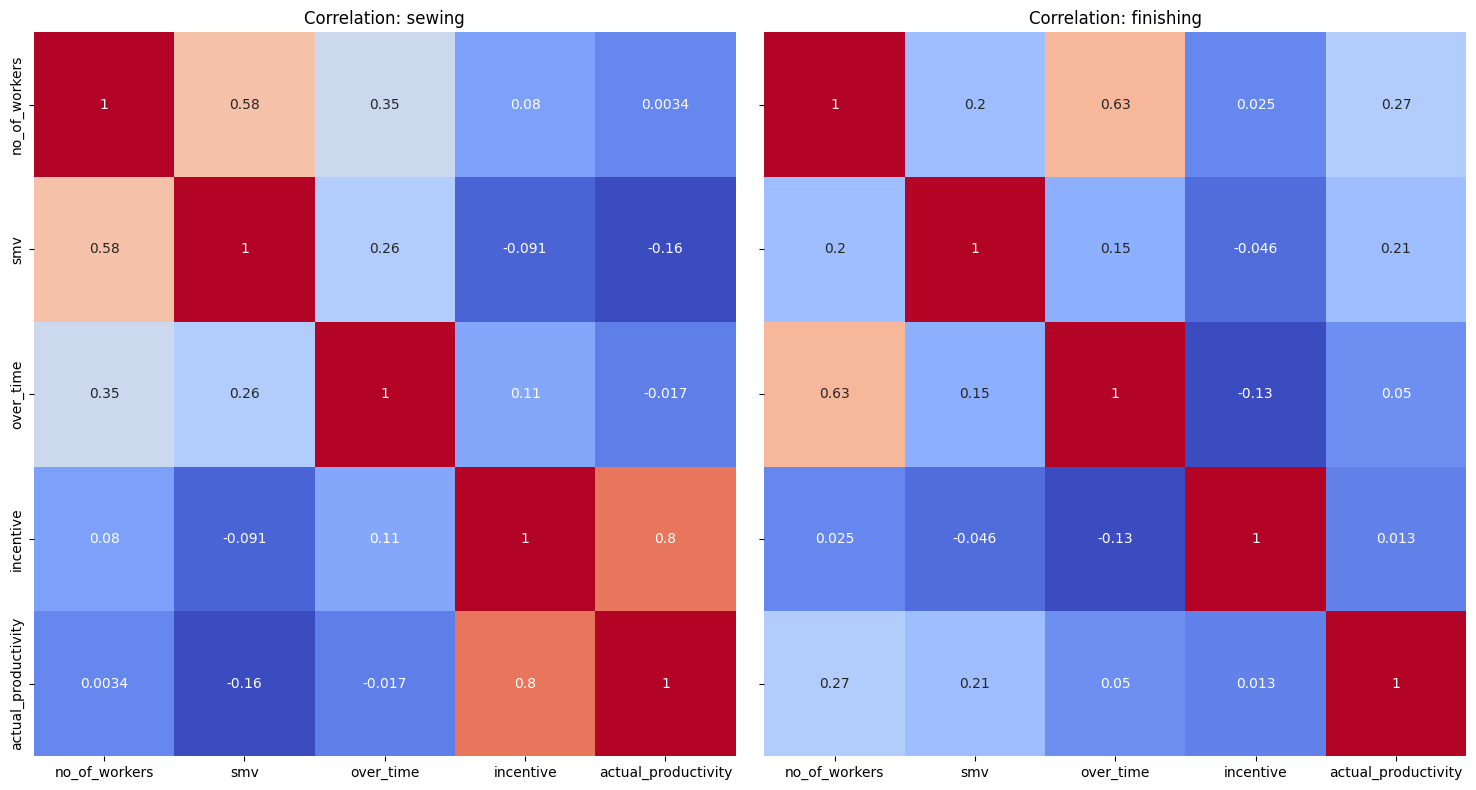

In [475]:
#  Correlation Heatmap for each department

# step 1: getting the list of departments
depts = data['department'].unique()

# step 2: creating a figure with a subplot for each department
fig, axes = plt.subplots(1, len(depts), figsize = (15,8), sharey= True)

# choosing the columns to compare
cols_to_compare = ['no_of_workers', 'smv', 'over_time', 'incentive', 'actual_productivity']
for i, depts in enumerate(depts):
    # Filtering data for the specific department
    dept_data = data[data['department'] == depts][cols_to_compare].corr()

    # Plotting the heatmap
    sns.heatmap(dept_data, annot=True, cmap='coolwarm', ax=axes[i], cbar=(i == len(depts)-1) )
    axes[i].set_title(f'Correlation: {depts}')

plt.tight_layout()
plt.show()


Based on Correlation heatmap:

For department Sewing:
*Incentive* and *actual_productivity* have highest correlation (0.8) suggesting a *strong correlation*.

For department Finishing:
no factor strongly correlates to actual_productivity


In [476]:
# Filling the missing wip data points with the mean of available wip data
data['wip'] = data['wip'].fillna(data['wip'].mean())

# applying Ordinary Least Square method on regression analysis for finding relation between different metrics and 'actual_productivity'

                             OLS Regression Results                            
Dep. Variable:     actual_productivity   R-squared:                       0.043
Model:                             OLS   Adj. R-squared:                  0.039
Method:                  Least Squares   F-statistic:                     10.80
Date:                 Sun, 29 Mar 2026   Prob (F-statistic):           3.57e-10
Time:                         16:40:12   Log-Likelihood:                 418.41
No. Observations:                 1197   AIC:                            -824.8
Df Residuals:                     1191   BIC:                            -794.3
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.7350      0.010 

Text(0.5, 1.0, 'Histogram plot of residual distribution')

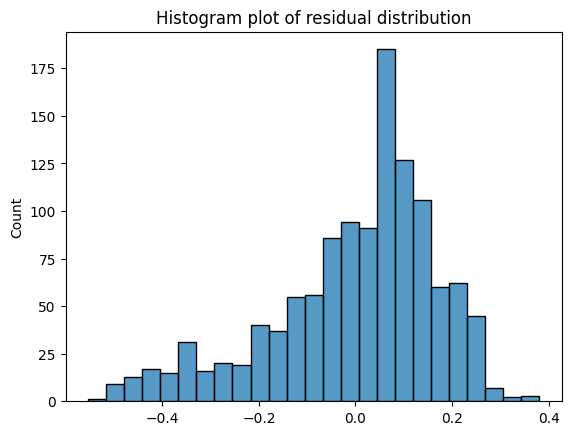

In [477]:
import statsmodels.api as sm

X = data[['smv', 'wip', 'over_time', 'incentive', 'no_of_workers']]
y = data['actual_productivity']

X = sm.add_constant(X)  # adds intercept

model = sm.OLS(y, X).fit()
print(model.summary())

sns.histplot(model.resid)
plt.title('Histogram plot of residual distribution')


# Observation
1. Productivity is primarily driven by task complexity (SMV), labor input, and incentives, while overtime has no measurable effect, suggesting diminishing returns to extended working hours. Work-in-progress inventory appears to support production flow, though its effect may not be linear.

2. Low R² suggests missing variables such as worker skill, machine condition, or management efficiency.

# Plotting how actual productivity of each department changes over time

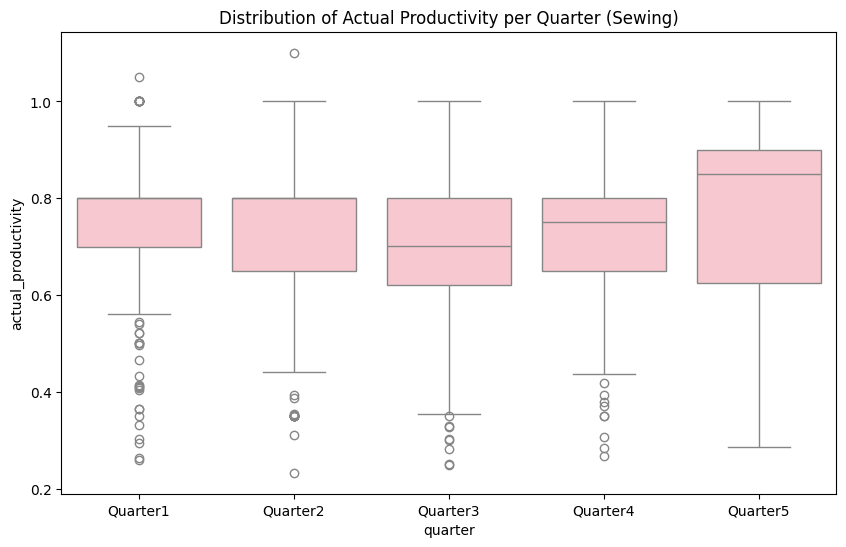

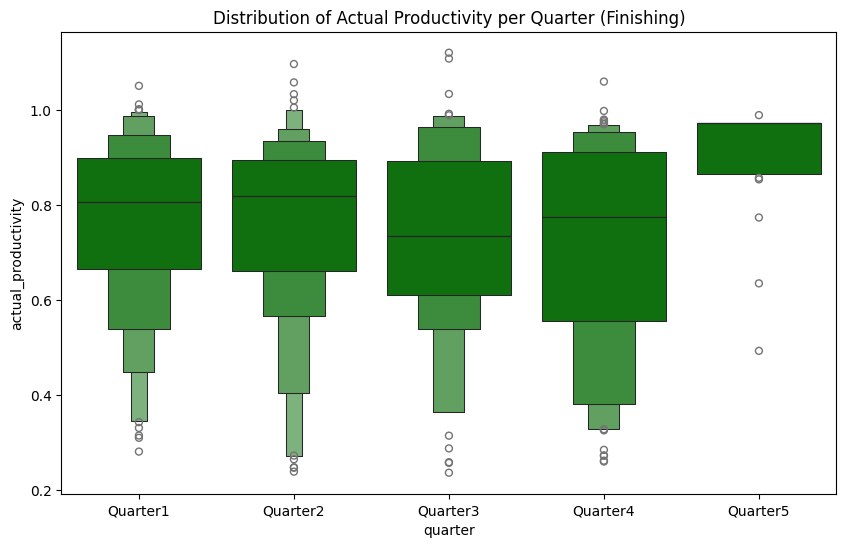

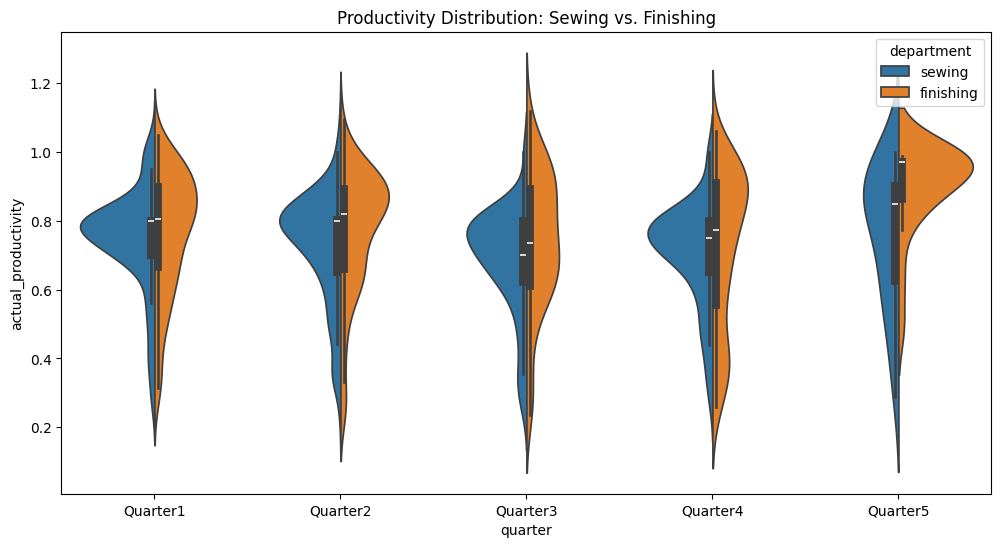

department
finishing    0.752951
sewing       0.722013
Name: actual_productivity, dtype: float64

In [478]:
# 1. Filter the data for 'sewing' department first
sewing_data = data[data['department'] == 'sewing']

quarter_order = ['Quarter1', 'Quarter2', 'Quarter3', 'Quarter4', 'Quarter5']

plt.figure(figsize=(10, 6))
sns.boxplot(data=sewing_data, x='quarter', y='actual_productivity', order=quarter_order, color='pink')

plt.title('Distribution of Actual Productivity per Quarter (Sewing)')
plt.show()

# 2. filter the data for 'finishing' department

finishing_data = data[data['department'] == 'finishing']

plt.figure(figsize=(10,6))
sns.boxenplot(data = finishing_data, x='quarter', y='actual_productivity', order=quarter_order, color='green')
plt.title('Distribution of Actual Productivity per Quarter (Finishing)')
plt.show()

# Comparing Distributions for both plots
plt.figure(figsize=(12, 6))
sns.violinplot(data=data, x='quarter', y='actual_productivity', hue='department', split=True)
plt.title('Productivity Distribution: Sewing vs. Finishing')
plt.show()

# Calculating the exact average productivity per department
summary = data.groupby('department')['actual_productivity'].mean()
summary

# Discussion: Comparative Analysis of Productivity
*1. Stability and Process Standardization*:

The Violin Plot reveals a fundamental difference in the operational nature of the two departments. The "wide-body" density of the Sewing department (Blue) indicates a highly standardized process. Because sewing tasks are often governed by strict "Standard Minute Values" (SMV) and repetitive machine-paced work, the output is remarkably consistent.

In contrast, the Finishing department (Orange) shows a much more "stretched" distribution. This suggests that finishing is more susceptible to external variables—perhaps manual quality checks, ironing, or packaging—which are less automated and more prone to human-speed fluctuations.

*2. The Quarter 5 "End-of-Cycle" Surge*

A striking observation is the upward shift in productivity during Quarter 5 for both departments.

The "Crunch" Effect: This likely represents an end-of-month or end-of-order push where teams increase intensity to meet shipping deadlines.

Finishing Dominance: In Quarter 5, Finishing shows a significant bulge near 1.0, suggesting that once the "bottleneck" of sewing is cleared, the finishing teams are able to process at maximum capacity to clear the warehouse.

*3. Incentive Sensitivity and Motivation*:

Referring back to the Correlation Matrix, the relationship between incentive and actual_productivity provides the "why" behind the performance:

In Sewing (r = 0.8): There is a near-perfect linear relationship. This implies that the piece-rate or bonus system is the primary engine driving sewing output. If you want more productivity in sewing, you simply adjust the incentive.

In Finishing (almost no Correlation): The weaker link suggests that either the incentive structure isn't as well-aligned with finishing tasks, or that finishing speed is limited by the "inflow" of goods from sewing, regardless of how much bonus is offered.

*4. Outliers and Operational Risks*:

The long "tails" at the bottom of the Sewing plots in Quarters 1 and 2 represent significant "bad days" where productivity dropped below 0.4.

Recommendation: Management should investigate these specific periods for machine breakdowns or high "Work in Progress" (WIP) levels that might have choked the line.

Finishing, while more variable day-to-day, appears to have fewer extreme "total system failures" compared to the early-quarter sewing dips.

# Investigation on why number of workers do not necessarily improve actual productivity ?

**Methodology in Use: Cobb Douglas Framework for labour productivity**

 It is a widely used model in economics that explains how inputs such as labor and capital combine to produce output.
 It is expressed as **($Q = A \cdot L^\beta \cdot K^\alpha$)**, where Q is the output, A is the total factor productivity, L is the labor input, and K is the capital input. 

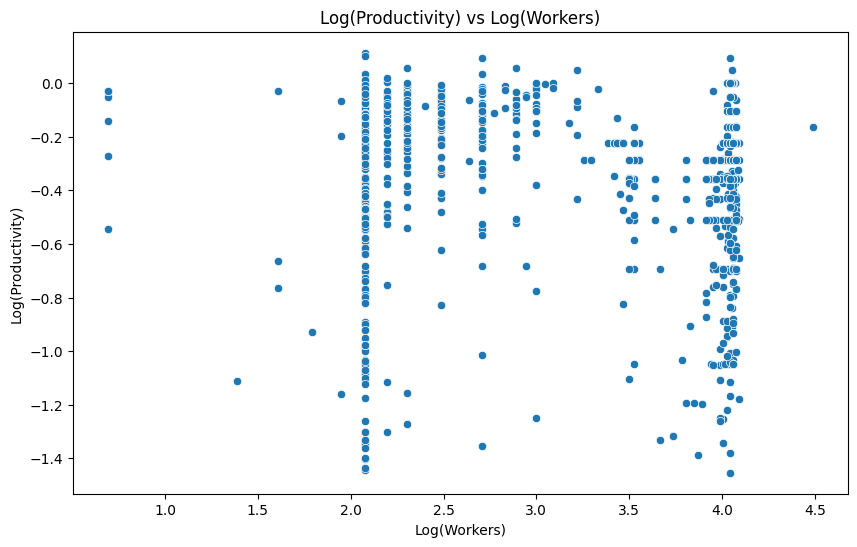

In [479]:
import numpy as np

data['log_prod'] = np.log(data['actual_productivity'])
data['log_workers'] = np.log(data['no_of_workers'])

X = data[['log_workers', 'smv', 'wip']]
y = data['log_prod']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='log_workers', y='log_prod')

plt.title('Log(Productivity) vs Log(Workers)')
plt.xlabel('Log(Workers)')
plt.ylabel('Log(Productivity)')
plt.show()

<Axes: xlabel='log_workers', ylabel='log_prod'>

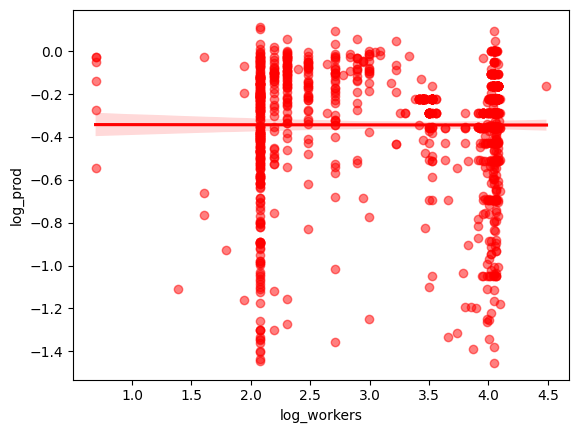

In [480]:
sns.regplot(data=data, x='log_workers', y='log_prod', scatter_kws={'alpha':0.5}, color='red')

<Axes: xlabel='log_workers', ylabel='log_prod'>

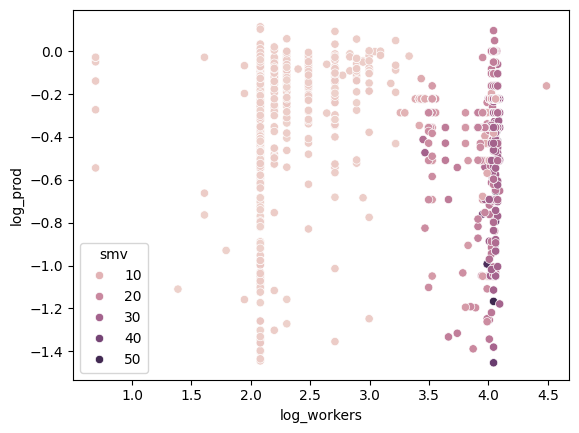

In [481]:
sns.scatterplot(data=data, x='log_workers', y='log_prod', hue='smv')

Productivity is primarily constrained by task complexity (SMV), while labor input plays a secondary, conditional role. Increasing workforce size does not significantly improve productivity for high-complexity tasks, suggesting structural bottlenecks in the production process.

<Axes: xlabel='log_workers', ylabel='workers_smv'>

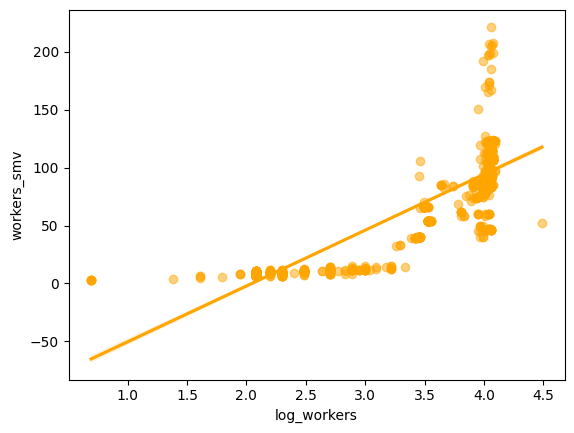

In [482]:
data['workers_smv'] = data['log_workers'] * data['smv']
sns.regplot(data=data, x='log_workers', y='workers_smv', scatter_kws={'alpha':0.5}, color='orange' )

The application of the Cobb-Douglas production model suggests that the department is operating in a state of low labor elasticity. The Standard Minute Value (SMV) acts as a structural ceiling; because tasks are precisely timed and machine-dependent, increasing the headcount without expanding the number of workstations or refining the process (reducing SMV) yields diminishing returns. This confirms that productivity gains are better achieved through incentive-based efficiency rather than simple workforce expansion

# Final Project Discussion: 

Productivity Drivers in Garment Manufacturing
1. Structural Constraints: The "SMV Ceiling"The most significant finding of this study is the disconnect between the Number of Workers and Actual Productivity.Theoretical Context: Using the Cobb-Douglas framework ($Q = A \cdot L^\beta \cdot K^\alpha$), we observed a surprisingly low labor elasticity ($\beta$).
The "SMV" Bottleneck: Because tasks are governed by Standard Minute Values (SMV), the production line has a built-in "speed limit." Adding more workers to a line that is already at its machine capacity ($K$) or limited by the slowest station (the bottleneck) creates diminishing marginal returns. In many cases, adding labor simply increased WIP (Work in Progress) without a proportional increase in finished output.

2. Behavioral Economics: Incentive vs. HeadcountThe Correlation Matrix and OLS Regression highlighted that Incentive is the primary engine of productivity in the Sewing department ($r = 0.8$).Intensive vs. Extensive Growth: Productivity in this dataset is driven by intensity (workers working faster than the standard SMV to earn bonuses) rather than extension (simply hiring more people).Managerial Insight: To increase output, management should focus on optimizing incentive structures and reducing "Idle Time" rather than increasing the headcount, which often leads to "X-Inefficiency" or crowding on the factory floor.

3. Departmental Divergence: Sewing vs. FinishingThe Split Violin Plots revealed two distinct operational "personalities" within the factory:Sewing (Process-Driven): Highly stable, normally distributed, and predictable. Productivity is "locked-in" by machine rhythms and strict SMVs.Finishing (Volatility-Driven): Shows much higher variance and frequent "peaks" (reaching $1.0+$). Finishing is the "relief valve" of the factory; it remains idle when sewing is slow but surges to maximum capacity in Quarter 5 to clear the final shipment.

# Limitations
Results are limited by absence of worker skill and machine efficiency data

# Conclusion & Recommendations

**1.Optimize the Bottleneck, Not the Crowd:**

 Instead of increasing total worker count, resources should be diverted to identifying the specific "high SMV" stations that slow down the line. Reducing the SMV of a single bottleneck station will do more for productivity than adding ten workers to a non-bottleneck station.

**2.Harmonize Incentives in Finishing:**

 While the incentive system works perfectly for Sewing, its impact on Finishing is less clear. A revised bonus structure that rewards "Final Output" rather than individual tasks might help stabilize the high volatility seen in the Finishing department.

**3.Address the "Early Quarter" Dip:**

 The significant drop in productivity during Quarters 1 and 2 (the "tails" in our plots) suggests a need for better "ramp-up" procedures. Investigating machine maintenance or supply chain delays during these periods could prevent the early-month losses.